In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fraud = pd.read_csv("../data/processed/fraud_processed.csv")

In [24]:
fraud.head()
fraud.shape

(14542, 28)

In [3]:
credit = pd.read_csv("../data/processed/credit_processed.csv")

In [4]:
X_fraud = fraud.drop("class", axis=1)
y_fraud = fraud["class"]

In [5]:
X_credit = credit.drop("Class", axis=1)
y_credit = credit["Class"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

In [ ]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(col)

device_id


In [15]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11633 entries, 8842 to 7466
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 11633 non-null  int64  
 1   purchase_value          11633 non-null  int64  
 2   device_id               11633 non-null  object 
 3   age                     11633 non-null  int64  
 4   ip_address              11633 non-null  int64  
 5   lower_bound_ip_address  11633 non-null  float64
 6   upper_bound_ip_address  11633 non-null  float64
 7   time_since_signup       11633 non-null  float64
 8   hour_of_day             11633 non-null  int64  
 9   day_of_week             11633 non-null  int64  
 10  user_tx_count           11633 non-null  int64  
 11  device_tx_count         11633 non-null  int64  
 12  transaction_velocity    0 non-null      float64
 13  source_Direct           11633 non-null  bool   
 14  source_SEO              11633 non-null  b

In [26]:
print(fraud.columns.tolist())

['user_id', 'purchase_value', 'device_id', 'age', 'ip_address', 'class', 'lower_bound_ip_address', 'upper_bound_ip_address', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_tx_count', 'device_tx_count', 'transaction_velocity', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Brazil', 'country_Canada', 'country_France', 'country_Germany', 'country_India', 'country_United Kingdom', 'country_United States']


In [27]:
y = fraud['class']

X = fraud.drop(
    ['class', 'device_id'],
    axis=1,
    errors='ignore'
)

In [32]:
X.select_dtypes(include=['object']).columns.tolist()

[]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

transaction_velocity    11633
dtype: int64

In [37]:
print(X_train.isnull().sum().sum())

11633


In [38]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [39]:
print(X_train.isnull().sum().sum())

11633


In [40]:
X_train = X_train.drop(columns=['transaction_velocity'])
X_test = X_test.drop(columns=['transaction_velocity'])

In [41]:
print(X_train.isnull().sum().sum())

0


In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(21174, 25)
class
0    10587
1    10587
Name: count, dtype: int64


In [43]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [44]:
print("Before SMOTE")
print(y_train.value_counts())

print("After SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
class
0    10587
1     1046
Name: count, dtype: int64
After SMOTE
class
0    10587
1    10587
Name: count, dtype: int64


In [45]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [46]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [47]:
f1_lr = f1_score(
    y_test,
    y_pred_lr
)

print("F1:", f1_lr)

F1: 0.2611885546588408


In [48]:
aucpr_lr = average_precision_score(
    y_test,
    y_prob_lr
)

print("AUC-PR:", aucpr_lr)

AUC-PR: 0.4330770201963651


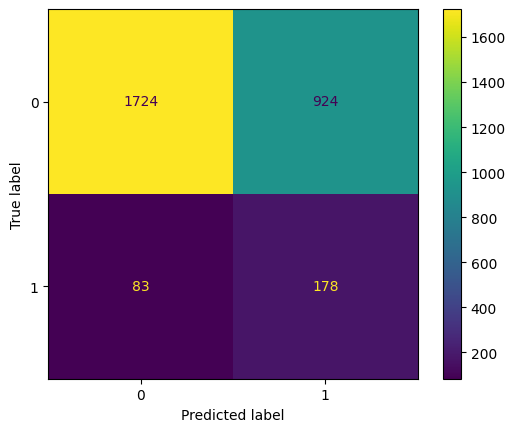

In [49]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [50]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.95      0.65      0.77      2648
           1       0.16      0.68      0.26       261

    accuracy                           0.65      2909
   macro avg       0.56      0.67      0.52      2909
weighted avg       0.88      0.65      0.73      2909



In [51]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [53]:
f1_rf = f1_score(
    y_test,
    y_pred_rf
)

aucpr_rf = average_precision_score(
    y_test,
    y_prob_rf
)

print("F1:", f1_rf)
print("AUC-PR:", aucpr_rf)

F1: 0.6258823529411764
AUC-PR: 0.6034183104939088


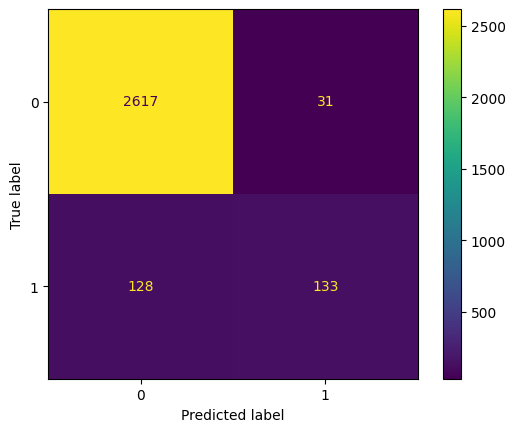

In [54]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [55]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

In [56]:
grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

In [57]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [58]:
best_rf = grid.best_estimator_

In [59]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [60]:
scores_lr = cross_val_score(
    lr,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring="f1"
)

print(
    scores_lr.mean(),
    scores_lr.std()
)

0.6879878643519166 0.009578520608072598


In [61]:
scores_rf = cross_val_score(
    best_rf,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring="f1"
)

print(
    scores_rf.mean(),
    scores_rf.std()
)

0.9525874618621388 0.003322430224236695


In [63]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "F1":[
        f1_lr,
        f1_rf
    ],
    "AUC_PR":[
        aucpr_lr,
        aucpr_rf
    ]
})

comparison

,Model,F1,AUC_PR
0,Logistic Regression,0.261189,0.433077
1,Random Forest,0.625882,0.603418


In [64]:
comparison.to_csv("../models/model_comparison.csv", index=False)

In [65]:
import joblib

joblib.dump(best_rf, "../models/best_fraud_model.pkl")

['../models/best_fraud_model.pkl']